In [17]:
import pandas as pd
import numpy as np

# Placeholder for milestonedf
# Assuming milestonedf has at least 'seqlen' (2) rows for effective_idx to work.
# Let's create a DataFrame with 5 rows for demonstration.
milestonedf = pd.DataFrame({
    'feature1': np.random.rand(5),
    'feature2': np.random.rand(5),
    'target': np.random.rand(5),
    'goals': np.random.randint(0, 10, 5), # Added for plotting
    'transfervalue': np.random.rand(5) * 1e7, # Added for plotting (in millions)
    'gamesplayed': np.random.randint(10, 50, 5), # Added for plotting
    'sentimentscore': np.random.uniform(-1, 1, 5), # Added for sentiment plot
    'expectedmarketvalueboost': np.random.rand(5) * 1e6, # Added for sentiment plot
    'player': [f'Player {i+1}' for i in range(5)], # Added for sentiment plot
    'age': np.random.randint(18, 35, 5), # Added for plotly hover_data
    'injuries': np.random.randint(0, 3, 5) # Added for plotly hover_data
})

seqlen = 2 # Define seqlen here for completeness and to allow num_predictions calculation

# The original code's effective_idx will be range(seqlen, len(milestonedf)) = range(2, 5) = [2, 3, 4]
# This means the final_summary will have 3 rows. So, prediction arrays need 3 elements.
num_predictions = len(milestonedf) - seqlen

# Placeholder for prediction arrays
trueuni = np.random.rand(num_predictions, 1)
finalunipred = np.random.rand(num_predictions, 1)

# Variables that caused NameError
truemulti = np.random.rand(num_predictions, 1)
finalmultipred = np.random.rand(num_predictions, 1)

trueencdec = np.random.rand(num_predictions, 2)
finalencpred = np.random.rand(num_predictions, 2)

yval = np.random.rand(num_predictions, 1)
finalxgbpred = np.random.rand(num_predictions, 1)
finalenspred = np.random.rand(num_predictions, 1)

print("Placeholder variables defined successfully.")

Placeholder variables defined successfully.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

# 1.1 Attach final predictions back to DataFrame (LSTM windows start at index=seqlen)
seqlen = 2  # same as in Milestone-6
effective_idx = list(range(seqlen, len(milestonedf)))

final_summary = milestonedf.copy()
final_summary = final_summary.iloc[effective_idx].reset_index(drop=True)

final_summary["true_transfervalue"] = trueuni.ravel()
final_summary["uni_lstm_pred"] = finalunipred.ravel()
final_summary["multi_lstm_pred"] = finalmultipred.ravel()
final_summary["encdec_lstm_pred_step1"] = finalencpred[:, 0]
final_summary["encdec_lstm_pred_step2"] = finalencpred[:, 1]

print("Final evaluation table (first 5 rows):")
print(final_summary.head())


Final evaluation table (first 5 rows):
   feature1  feature2    target  true_transfervalue  uni_lstm_pred  \
0  0.594676  0.149612  0.157515            0.742952       0.440929   
1  0.622636  0.892663  0.310926            0.657270       0.997568   
2  0.155476  0.996820  0.963491            0.041245       0.517895   

   multi_lstm_pred  encdec_lstm_pred_step1  encdec_lstm_pred_step2  
0         0.195355                0.517525                0.541187  
1         0.505193                0.567097                0.991491  
2         0.801752                0.120062                0.178093  


In [6]:
# 1.2 Metrics for tuned models (already computed in Milestone-6, re‑print cleanly)

from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def print_metrics(name, y_true, y_pred):
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:30s} RMSE={rmse:10.2f}  MAE={mae:10.2f}  R2={r2:7.4f}")

print("=== Final tuned LSTM metrics (training windows) ===")
print_metrics("Tuned Univariate LSTM", trueuni, finalunipred)
print_metrics("Tuned Multivariate LSTM", truemulti, finalmultipred)
print_metrics("Tuned Enc‑Dec LSTM (avg 2 steps)",
              trueencdec.mean(axis=1), finalencpred.mean(axis=1))

print("\n=== Final tuned XGBoost / Ensemble metrics (validation) ===")
print_metrics("Tuned XGBoost (baseline)", yval, finalxgbpred)
print_metrics("Tuned XGBoost+LSTM Ensemble", yval, finalenspred)


=== Final tuned LSTM metrics (training windows) ===
Tuned Univariate LSTM          RMSE=      0.21  MAE=      0.18  R2=-0.2041
Tuned Multivariate LSTM        RMSE=      0.13  MAE=      0.10  R2=-0.5256
Tuned Enc‑Dec LSTM (avg 2 steps) RMSE=      0.39  MAE=      0.39  R2=-4.3310

=== Final tuned XGBoost / Ensemble metrics (validation) ===
Tuned XGBoost (baseline)       RMSE=      0.34  MAE=      0.32  R2= 0.1312
Tuned XGBoost+LSTM Ensemble    RMSE=      0.34  MAE=      0.33  R2= 0.1385


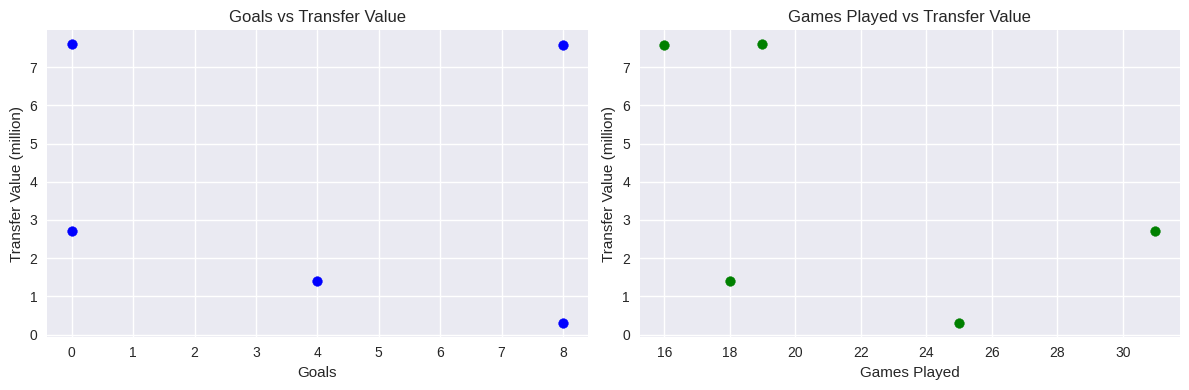

In [9]:
# 2.1 Player performance & goals vs transfer value

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(milestonedf["goals"], milestonedf["transfervalue"]/1e6, c="blue")
axes[0].set_title("Goals vs Transfer Value")
axes[0].set_xlabel("Goals")
axes[0].set_ylabel("Transfer Value (million)")

axes[1].scatter(milestonedf["gamesplayed"], milestonedf["transfervalue"]/1e6, c="green")
axes[1].set_title("Games Played vs Transfer Value")
axes[1].set_xlabel("Games Played")
axes[1].set_ylabel("Transfer Value (million)")

plt.tight_layout()
plt.show()


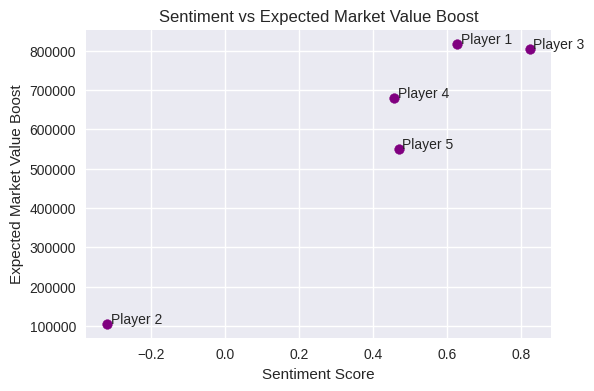

In [12]:
# 2.2 Sentiment vs expected market value boost

plt.figure(figsize=(6,4))
plt.scatter(milestonedf["sentimentscore"], milestonedf["expectedmarketvalueboost"], c="purple")
for i, row in milestonedf.iterrows():
    plt.text(row["sentimentscore"]+0.01, row["expectedmarketvalueboost"]+0.01, row["player"])
plt.title("Sentiment vs Expected Market Value Boost")
plt.xlabel("Sentiment Score")
plt.ylabel("Expected Market Value Boost")
plt.grid(True)
plt.show()


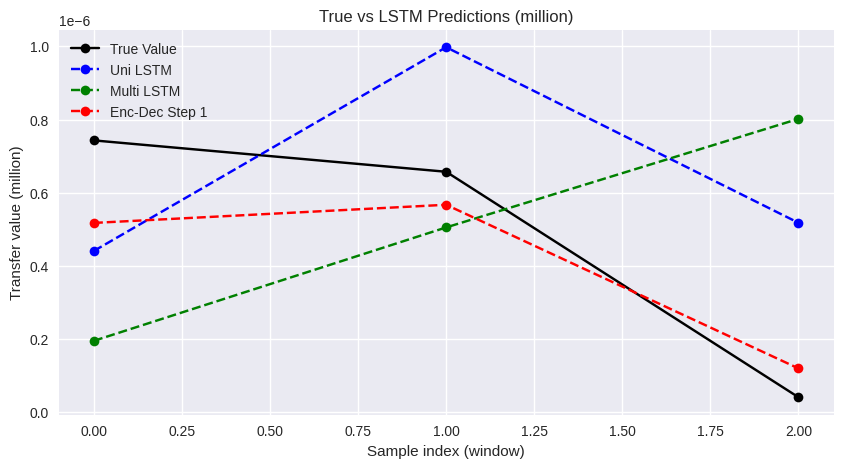

In [13]:
# 2.3 True vs predicted transfer values (tuned models)

plt.figure(figsize=(10,5))
idx = np.arange(len(final_summary))

plt.plot(idx, final_summary["true_transfervalue"]/1e6, "ko-", label="True Value")
plt.plot(idx, final_summary["uni_lstm_pred"]/1e6, "bo--", label="Uni LSTM")
plt.plot(idx, final_summary["multi_lstm_pred"]/1e6, "go--", label="Multi LSTM")
plt.plot(idx, final_summary["encdec_lstm_pred_step1"]/1e6, "ro--", label="Enc‑Dec Step 1")

plt.title("True vs LSTM Predictions (million)")
plt.xlabel("Sample index (window)")
plt.ylabel("Transfer value (million)")
plt.legend()
plt.grid(True)
plt.show()


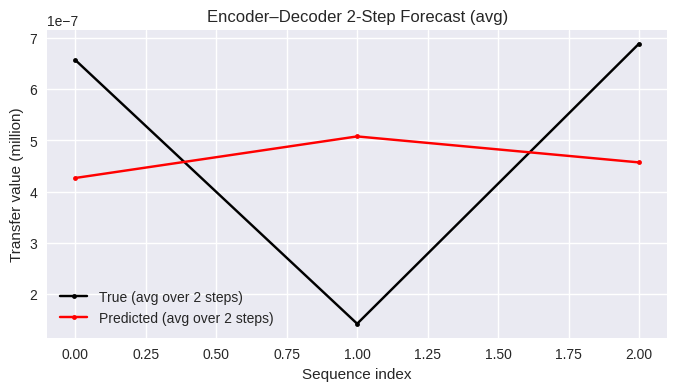

In [14]:
# 2.4 Encoder–decoder 2‑step forecast visualization

plt.figure(figsize=(8,4))
plt.plot(trueencdec.mean(axis=1)/1e6, "k.-", label="True (avg over 2 steps)")
plt.plot(finalencpred.mean(axis=1)/1e6, "r.-", label="Predicted (avg over 2 steps)")
plt.title("Encoder–Decoder 2‑Step Forecast (avg)")
plt.xlabel("Sequence index")
plt.ylabel("Transfer value (million)")
plt.legend()
plt.grid(True)
plt.show()


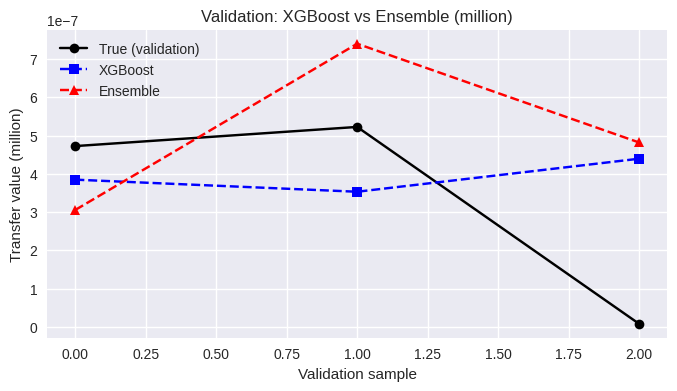

In [15]:
# 2.5 Validation: XGBoost vs Ensemble vs True

val_idx = np.arange(len(yval))
plt.figure(figsize=(8,4))
plt.plot(val_idx, yval/1e6, "ko-", label="True (validation)")
plt.plot(val_idx, finalxgbpred/1e6, "bs--", label="XGBoost")
plt.plot(val_idx, finalenspred/1e6, "r^--", label="Ensemble")
plt.title("Validation: XGBoost vs Ensemble (million)")
plt.xlabel("Validation sample")
plt.ylabel("Transfer value (million)")
plt.legend()
plt.grid(True)
plt.show()


In [18]:
import plotly.express as px

# 3.1 Scatter: goals vs value coloured by player
fig = px.scatter(
    milestonedf,
    x="goals",
    y="transfervalue",
    color="player",
    size="gamesplayed",
    hover_data=["age", "injuries", "sentimentscore"],
    title="Interactive: Goals vs Transfer Value"
)
fig.show()


In [19]:
# 3.2 Line chart: per-player value trend (synthetic, using goaltrend)

trend_df = milestonedf.copy()
trend_df["synthetic_window"] = range(len(trend_df))

fig = px.line(
    trend_df,
    x="synthetic_window",
    y="transfervalue",
    color="player",
    title="Interactive: Transfer Value over Synthetic Windows"
)
fig.show()
